<p align="center"><img src="PAQu.png" width="160"/></p>

# PAQu — Vignette

This notebook walks through a complete PAQu analysis on a fully synthetic dataset.
No external data files are required.

**Model at a glance**

```
I  =  I₀  +  T × W  +  A × D  +  noise       (isoform equation)
P  ≈  I × Z  +  noise                          (peptide equation)
```

| Symbol | Meaning | Role |
|--------|---------|------|
| **P** | Observed peptide intensities (n × r) | Input |
| **T** | Transcript expression (n × q) | Input |
| **A** | Binary condition label (n) | Input |
| **M** | Peptide–isoform compatibility mask (q × r) | Input |
| **I** | Latent isoform abundances (n × q) | Estimated |
| **I₀** | Baseline abundance per isoform (q) | Estimated |
| **W** | Transcript-to-isoform coupling (q) | Estimated |
| **D** | Condition effect per isoform (q) | Estimated |
| **Z** | Peptide-to-isoform weights (q × r) | Estimated |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import truncnorm

from PAQu import PAQu

plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

---
## 1. Synthetic dataset

We simulate **n = 100** samples (50 controls, 50 cases), **q = 3** isoforms and **r = 8** peptides.
Isoform 0 is the only truly differentially expressed isoform (D = 1.0).

In [2]:
np.random.seed(42)

n, q, r = 100, 3, 8
n_iter  = 1000
burn_in = 500

# ------------------------------------------------------------------
# True parameters
# ------------------------------------------------------------------
A       = np.array([0]*50 + [1]*50)        # condition labels (0 = control, 1 = case)
I0_true = np.array([10.0,  8.0, 12.0])    # baseline abundances
D_true  = np.array([ 1.0,  0.0,  0.0])    # isoform 0 is truly DE
W_true  = np.array([ 0.8,  1.2,  0.6])    # transcript coupling

T = np.random.normal(3, 1, (n, q))         # transcript expression

I_true = (np.ones((n, 1)) @ I0_true[None, :]
          + T * W_true[None, :]
          + np.outer(A, D_true)
          + np.random.normal(0, 1, (n, q)))

# Peptide–isoform compatibility mask
M = np.array([
    [1, 1, 1, 0, 0, 0, 1, 0],   # isoform 0
    [0, 1, 0, 1, 1, 0, 0, 1],   # isoform 1
    [0, 0, 1, 0, 1, 1, 1, 0],   # isoform 2
])

# True Z: peptide weights ~ TruncNorm(mean=1, sd=0.3) restricted to [0.5, 1.5]
a_t, b_t = (0.5 - 1.0) / 0.3, (1.5 - 1.0) / 0.3
Z_true = truncnorm.rvs(a_t, b_t, loc=1.0, scale=0.3, size=(q, r)) * M

# Observed peptide intensities
P = I_true @ Z_true + np.random.normal(0, 1, (n, r))

print(f'P shape : {P.shape}   (samples × peptides)')
print(f'T shape : {T.shape}   (samples × isoforms)')
print(f'M shape : {M.shape}   (isoforms × peptides)')
print(f'Truly DE isoforms: {np.where(D_true != 0)[0].tolist()}')

P shape : (100, 8)   (samples × peptides)
T shape : (100, 3)   (samples × isoforms)
M shape : (3, 8)   (isoforms × peptides)
Truly DE isoforms: [0]


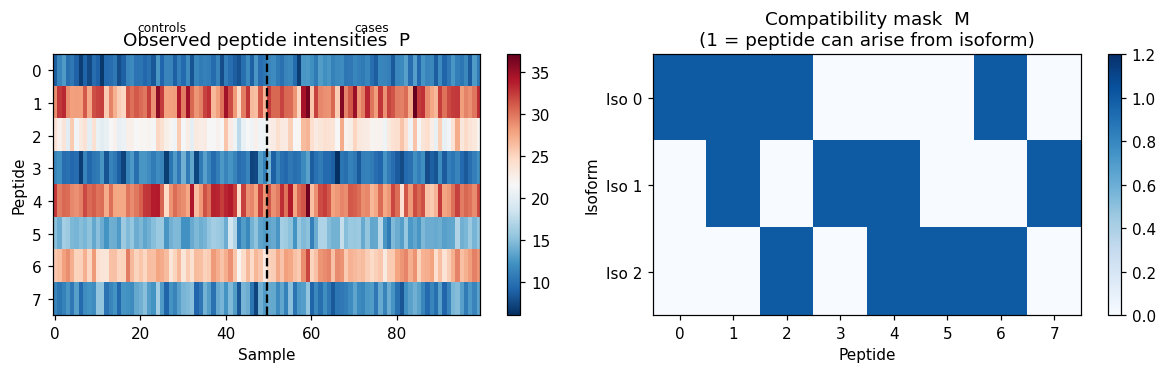

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

# Peptide intensity matrix
im = axes[0].imshow(P.T, aspect='auto', cmap='RdBu_r')
axes[0].axvline(49.5, color='black', lw=1.5, ls='--')
axes[0].set_xlabel('Sample')
axes[0].set_ylabel('Peptide')
axes[0].set_title('Observed peptide intensities  P')
axes[0].text(25, -1.2, 'controls', ha='center', fontsize=8)
axes[0].text(74, -1.2, 'cases',    ha='center', fontsize=8)
plt.colorbar(im, ax=axes[0])

# Compatibility mask
im2 = axes[1].imshow(M, aspect='auto', cmap='Blues', vmin=0, vmax=1.2)
axes[1].set_xlabel('Peptide')
axes[1].set_ylabel('Isoform')
axes[1].set_yticks(range(q))
axes[1].set_yticklabels([f'Iso {j}' for j in range(q)])
axes[1].set_title('Compatibility mask  M\n(1 = peptide can arise from isoform)')
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()

---
## 2. Fitting PAQu

Construct the model, optionally adjust hyperparameters with `update_hyperparameters()`, then call `fit()`.
The Gibbs sampler stores every iterate; posterior summaries are computed after discarding the burn-in.

In [4]:
model = PAQu(A=A, M=M, P=P, T=T)

# Prior hyperparameters can be tuned before fitting
model.update_hyperparameters('scaleDj', 3)
model.update_hyperparameters('shapeDj', 0.5)

model.fit(n_iter=n_iter, fit_intercept=True, prior_D='Gaussian')
print(f'Fit time: {model.fit_time:.1f} s')

Fitting PAQu


Fit time: 6.3 s


---
## 3. Convergence diagnostics

`plot_convergence()` shows a trace plot and running mean for each selected parameter × isoform pair.
The red dashed line marks the burn-in cutoff.

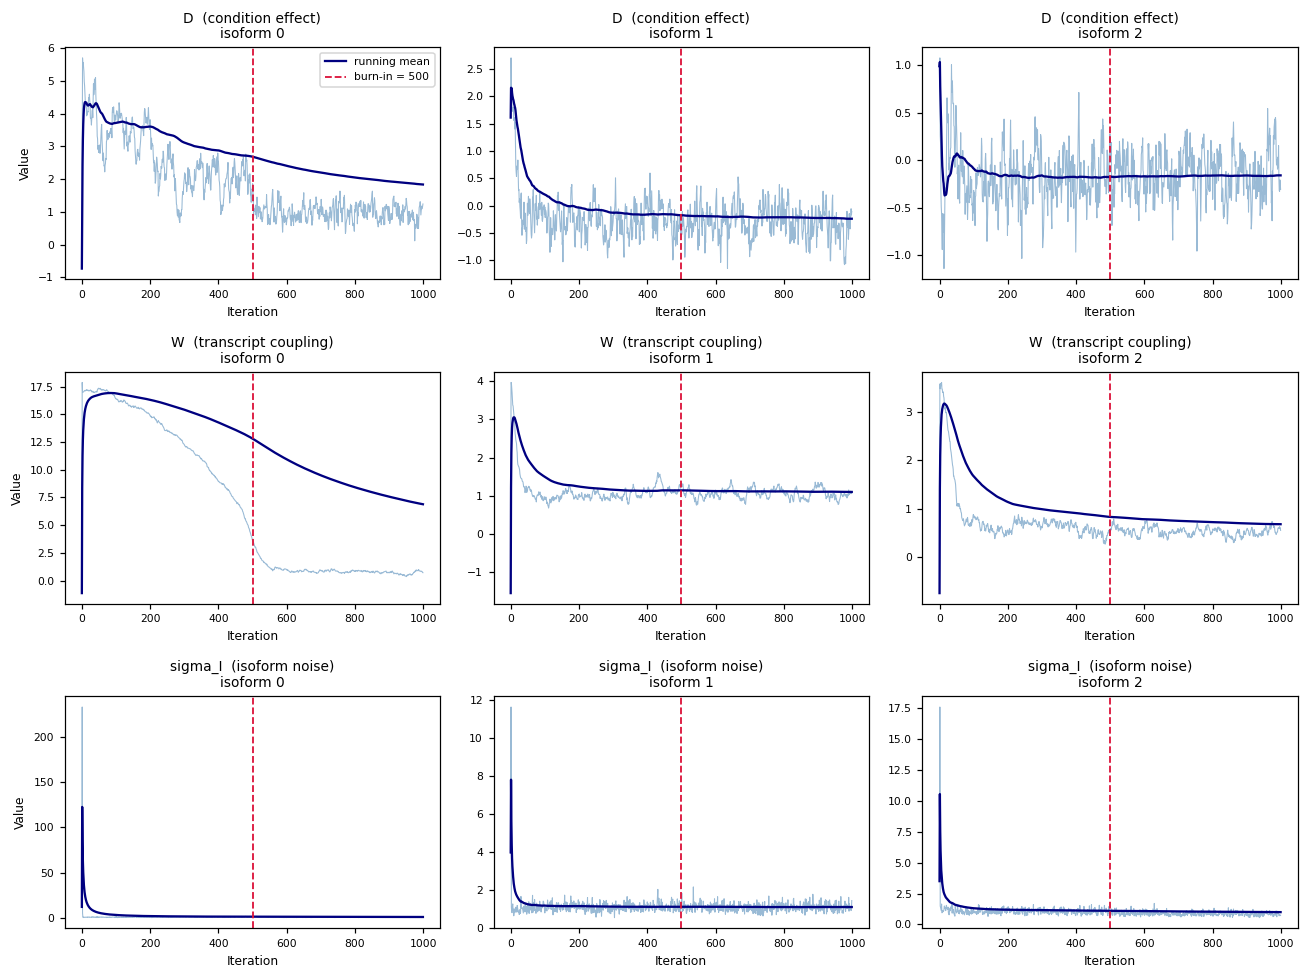

In [5]:
fig = model.plot_convergence(
    params=('D_storer', 'W_storer', 'sigmaI_storer'),
    burn_in=burn_in
)
plt.show()

---
## 4. Differential expression

**D** captures the condition effect on each isoform's abundance.
The **Local False Sign Rate (LFSR)** — the posterior probability that the sign of D is wrong — is used to call DE isoforms.
LFSR ≤ 0.05 is a standard threshold.

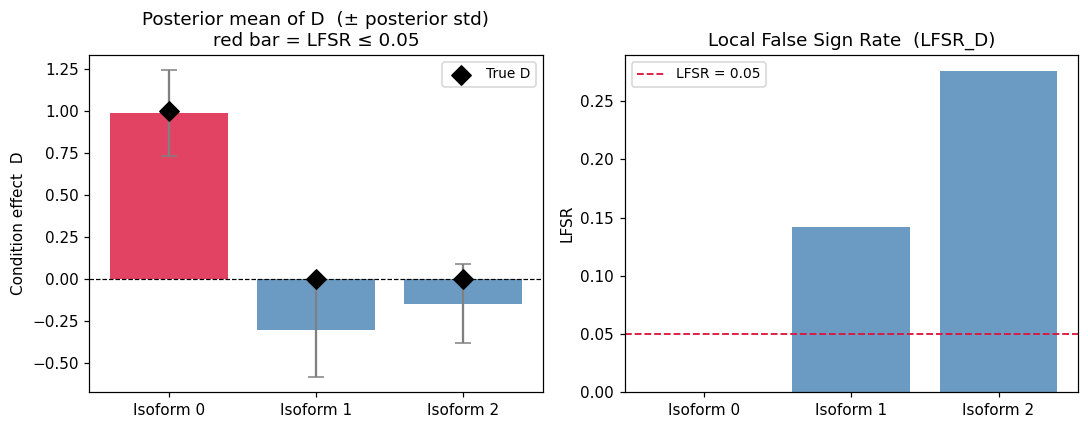

Isoform 0:  D_hat = +0.987  (true = +1.0)   LFSR = 0.0000  ← DE
Isoform 1:  D_hat = -0.301  (true = +0.0)   LFSR = 0.1420
Isoform 2:  D_hat = -0.146  (true = +0.0)   LFSR = 0.2760


In [6]:
D_hat  = model.D_storer[burn_in:].mean(axis=0)
D_std  = model.D_storer[burn_in:].std(axis=0)
lfsr_D = model.LFSR('D_storer', burn_in)

colors = ['crimson' if l <= 0.05 else 'steelblue' for l in lfsr_D]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Posterior mean of D
axes[0].bar(range(q), D_hat, yerr=D_std, color=colors, alpha=0.8,
            capsize=5, ecolor='grey')
axes[0].scatter(range(q), D_true, color='black', zorder=5, s=80,
                marker='D', label='True D')
axes[0].axhline(0, color='black', lw=0.8, ls='--')
axes[0].set_xticks(range(q))
axes[0].set_xticklabels([f'Isoform {j}' for j in range(q)])
axes[0].set_ylabel('Condition effect  D')
axes[0].set_title('Posterior mean of D  (± posterior std)\nred bar = LFSR ≤ 0.05')
axes[0].legend(fontsize=9)

# LFSR
axes[1].bar(range(q), lfsr_D, color=colors, alpha=0.8)
axes[1].axhline(0.05, color='crimson', ls='--', lw=1.2, label='LFSR = 0.05')
axes[1].set_xticks(range(q))
axes[1].set_xticklabels([f'Isoform {j}' for j in range(q)])
axes[1].set_ylabel('LFSR')
axes[1].set_title('Local False Sign Rate  (LFSR_D)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

for j in range(q):
    flag = '  ← DE' if lfsr_D[j] <= 0.05 else ''
    print(f'Isoform {j}:  D_hat = {D_hat[j]:+.3f}  (true = {D_true[j]:+.1f})   LFSR = {lfsr_D[j]:.4f}{flag}')

---
## 5. Transcript–isoform coupling

**W** captures how strongly each isoform's abundance tracks its transcript expression level.
Large |W| with low LFSR_W indicates reliable transcript-to-protein coupling for that isoform.

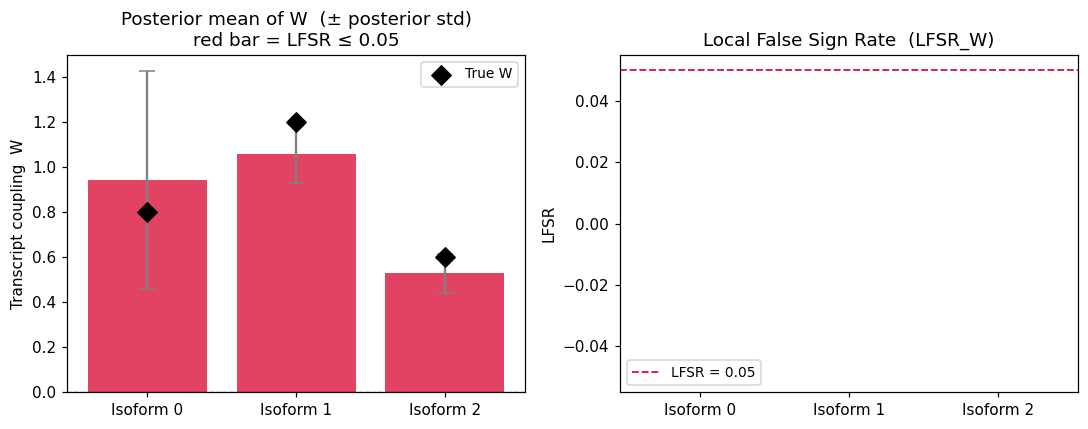

In [7]:
W_hat  = model.W_storer[burn_in:].mean(axis=0)
W_std  = model.W_storer[burn_in:].std(axis=0)
lfsr_W = model.LFSR('W_storer', burn_in)

colors_W = ['crimson' if l <= 0.05 else 'steelblue' for l in lfsr_W]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(range(q), W_hat, yerr=W_std, color=colors_W, alpha=0.8,
            capsize=5, ecolor='grey')
axes[0].scatter(range(q), W_true, color='black', zorder=5, s=80,
                marker='D', label='True W')
axes[0].axhline(0, color='black', lw=0.8, ls='--')
axes[0].set_xticks(range(q))
axes[0].set_xticklabels([f'Isoform {j}' for j in range(q)])
axes[0].set_ylabel('Transcript coupling  W')
axes[0].set_title('Posterior mean of W  (± posterior std)\nred bar = LFSR ≤ 0.05')
axes[0].legend(fontsize=9)

axes[1].bar(range(q), lfsr_W, color=colors_W, alpha=0.8)
axes[1].axhline(0.05, color='crimson', ls='--', lw=1.2, label='LFSR = 0.05')
axes[1].set_xticks(range(q))
axes[1].set_xticklabels([f'Isoform {j}' for j in range(q)])
axes[1].set_ylabel('LFSR')
axes[1].set_title('Local False Sign Rate  (LFSR_W)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## 6. Isoform abundance recovery

**I** is the latent n × q matrix of per-sample isoform abundances.
Each panel below shows the true vs estimated abundance across all n samples for one isoform.
Points are coloured by condition.

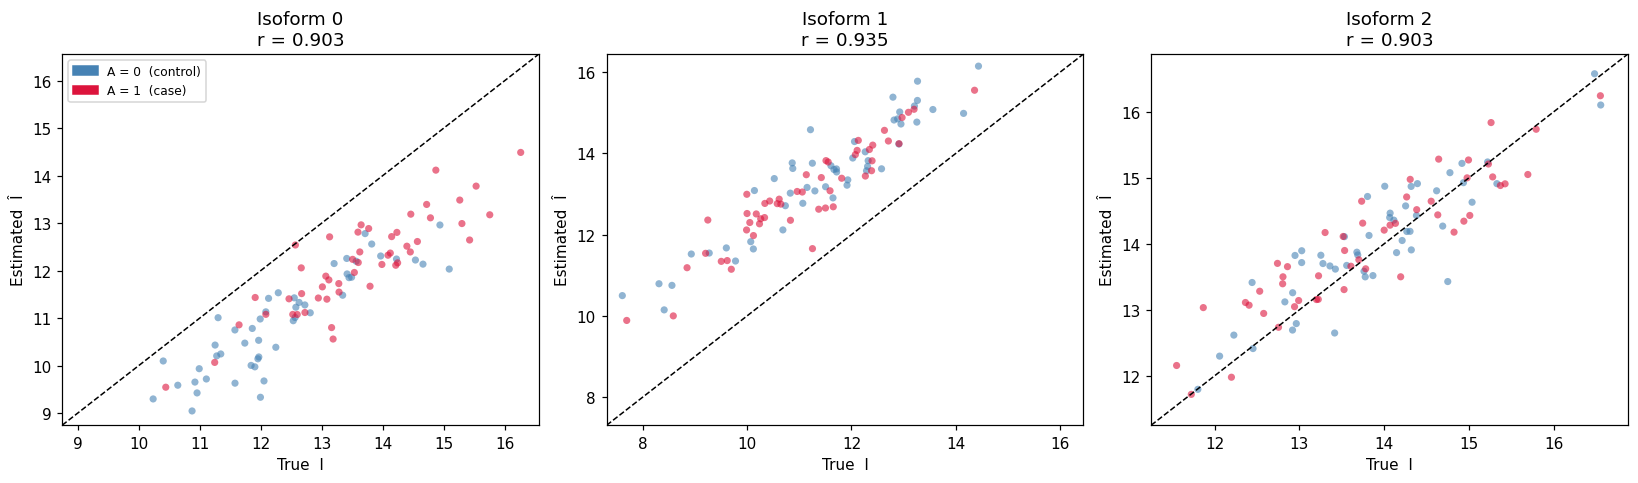

In [8]:
I_hat = model.I_storer[burn_in:].mean(axis=0)   # shape: (n, q)

ctrl = mpatches.Patch(color='steelblue', label='A = 0  (control)')
case = mpatches.Patch(color='crimson',   label='A = 1  (case)')
c    = np.where(A == 0, 'steelblue', 'crimson')

fig, axes = plt.subplots(1, q, figsize=(5 * q, 4.5))
for j in range(q):
    x, y = I_true[:, j], I_hat[:, j]
    cor  = np.corrcoef(x, y)[0, 1]
    lo   = min(x.min(), y.min()) - 0.3
    hi   = max(x.max(), y.max()) + 0.3

    axes[j].scatter(x, y, c=c, alpha=0.6, s=22, linewidths=0)
    axes[j].plot([lo, hi], [lo, hi], 'k--', lw=1)
    axes[j].set_xlim(lo, hi)
    axes[j].set_ylim(lo, hi)
    axes[j].set_xlabel('True  I')
    axes[j].set_ylabel('Estimated  Î')
    axes[j].set_title(f'Isoform {j}\nr = {cor:.3f}')
    if j == 0:
        axes[j].legend(handles=[ctrl, case], fontsize=8)

plt.tight_layout()
plt.show()

---
## 7. Peptide-to-isoform weights  Z

**Z** (q × r) gives the weight of each peptide for each isoform, constrained to zero outside the compatibility mask M.
The posterior mean of Z should recover the true weights where M = 1.

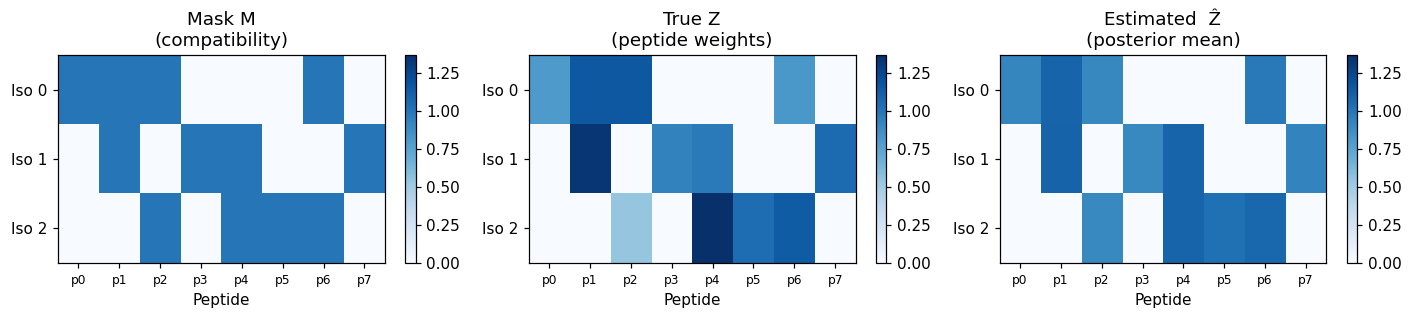

In [9]:
Z_hat = model.Z_storer[burn_in:].mean(axis=0)   # shape: (q, r)

vmax = max(Z_true.max(), Z_hat.max())

fig, axes = plt.subplots(1, 3, figsize=(13, 3))
for ax, data, title in zip(
        axes,
        [M,      Z_true,           Z_hat],
        ['Mask M\n(compatibility)', 'True Z\n(peptide weights)', 'Estimated  Ẑ\n(posterior mean)']):
    im = ax.imshow(data, cmap='Blues', aspect='auto', vmin=0, vmax=vmax)
    ax.set_yticks(range(q))
    ax.set_yticklabels([f'Iso {j}' for j in range(q)])
    ax.set_xticks(range(r))
    ax.set_xticklabels([f'p{k}' for k in range(r)], fontsize=8)
    ax.set_xlabel('Peptide')
    ax.set_title(title)
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

---
## 8. Accessing the full posterior

All MCMC iterates are stored as NumPy arrays and remain accessible after `fit()`.
This makes it straightforward to compute any custom posterior summary.

In [10]:
print('Storer shapes after fit():')
for name in ['D_storer', 'W_storer', 'I_storer', 'Z_storer',
             'I0_storer', 'pi_storer', 'sigmaI_storer', 'sigmaP_storer']:
    print(f'  model.{name}: {getattr(model, name).shape}')

# LFSR for any 2-D storer (n_iter, q)
print('\nLFSR_D:', model.LFSR('D_storer', burn_in).round(4))
print('LFSR_W:', model.LFSR('W_storer', burn_in).round(4))

# Credible intervals via the built-in helper
ci_lo, ci_hi = model.credible_interval('D_storer', burn_in, prob=0.95)
print('\n95% credible intervals for D:')
for j in range(q):
    print(f'  Isoform {j}: [{ci_lo[j]:+.3f},  {ci_hi[j]:+.3f}]   (true = {D_true[j]:+.1f})')


Storer shapes after fit():
  model.D_storer: (1000, 3)
  model.W_storer: (1000, 3)
  model.I_storer: (1000, 100, 3)
  model.Z_storer: (1000, 3, 8)
  model.I0_storer: (1000, 3)
  model.pi_storer: (1000, 3)
  model.sigmaI_storer: (1000, 3)
  model.sigmaP_storer: (1000, 8)

LFSR_D: [0.    0.142 0.276]
LFSR_W: [0. 0. 0.]

95% credible intervals for D:
  Isoform 0: [+0.537,  +1.499]   (true = +1.0)
  Isoform 1: [-0.868,  +0.247]   (true = +0.0)
  Isoform 2: [-0.617,  +0.280]   (true = +0.0)
